# AIG/Graph -> Area/Delay/Power prediction 

In [1]:
#imports

import torch
import os
import zipfile
import pickle
from pprint import pprint
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
import numpy as np

#### *preprocessed pytorch data using (openabc-d)*

In [2]:
!ls ./OpenABC_Dataset/ptdata/processed/

adder_syn0_step0.pt.zip    i2c_syn100_step0.pt.zip  sin_syn0_step0.pt.zip
adder_syn100_step0.pt.zip  i2c_syn101_step0.pt.zip  sin_syn100_step0.pt.zip
adder_syn101_step0.pt.zip  i2c_syn102_step0.pt.zip  sin_syn101_step0.pt.zip
adder_syn102_step0.pt.zip  i2c_syn103_step0.pt.zip  sin_syn102_step0.pt.zip
adder_syn103_step0.pt.zip  i2c_syn104_step0.pt.zip  sin_syn103_step0.pt.zip
adder_syn104_step0.pt.zip  i2c_syn105_step0.pt.zip  sin_syn104_step0.pt.zip
adder_syn105_step0.pt.zip  i2c_syn106_step0.pt.zip  sin_syn105_step0.pt.zip
adder_syn106_step0.pt.zip  i2c_syn107_step0.pt.zip  sin_syn106_step0.pt.zip
adder_syn107_step0.pt.zip  i2c_syn108_step0.pt.zip  sin_syn107_step0.pt.zip
adder_syn108_step0.pt.zip  i2c_syn109_step0.pt.zip  sin_syn108_step0.pt.zip
adder_syn109_step0.pt.zip  i2c_syn10_step0.pt.zip   sin_syn109_step0.pt.zip
adder_syn10_step0.pt.zip   i2c_syn110_step0.pt.zip  sin_syn10_step0.pt.zip
adder_syn110_step0.pt.zip  i2c_syn111_step0.pt.zip  sin_syn110_step0.pt.zip
adder_syn111_st

In [3]:
# Load Graphs into a list

zip_folder_path = "./OpenABC_Dataset/ptdata/processed/"

graphs = []

for file_name in os.listdir(zip_folder_path):
    if file_name.endswith(".zip"):
        zip_path = os.path.join(zip_folder_path, file_name)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:

            pt_files = [f for f in zip_ref.namelist() if f.endswith(".pt")]
            
            if len(pt_files) != 1:
                print(f"Skipping {file_name}: Expected 1 .pt file, found {len(pt_files)}")
                continue
            
            pt_filename = pt_files[0]
            
            zip_ref.extract(pt_filename, zip_folder_path)
            
            extracted_pt_path = os.path.join(zip_folder_path, pt_filename)
            
            graph = torch.load(extracted_pt_path, weights_only=False)
            graphs.append(graph)
            
            os.remove(extracted_pt_path)

print(f"Loaded {len(graphs)} graphs.")

Loaded 900 graphs.


In [4]:
graphs

[Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[20], synID=[1], stepID=[1]),
 Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[20], synID=[1], stepID=[1]),
 Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[20], synID=[1], stepID=[1]),
 Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[2

<br>

## Graph Statistics

In [5]:
len(graphs)

900

In [6]:
graphs[0].desName

['adder']

#### *0 - PI, 1 - PO, 2 = Intermediate*

In [7]:
graphs[0].node_type

tensor([0, 0, 0,  ..., 2, 2, 1])

In [8]:
graphs[0].num_inverted_predecessors

tensor([0, 0, 0,  ..., 2, 2, 1])

#### *Synthesis Transformations*

- 0 : refactor
- 1 : refactor -z
- 2 : rewrite
- 3 : rewrite -z
- 4 : resub
- 5 : resub -z
- 6 : balance

In [9]:
graphs[0].synVec

tensor([0, 3, 3, 4, 0, 0, 2, 2, 3, 6, 0, 0, 5, 6, 6, 6, 6, 0, 4, 1])

In [10]:
graphs[0].synID # This ID will be used to map the target values

[3]

In [11]:
graphs[101].synID

[93]

<br>

## Graphs Labelling

In [12]:
!ls OpenABC_Dataset/statistics/

adp  finalAig  synthesisStatistics.pickle


In [13]:
pickle_path = "OpenABC_Dataset/statistics/synthesisStatistics.pickle"

with open(pickle_path, "rb") as f:
    data = pickle.load(f)

pprint(data)

{'adder': [[1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
            1020,
          

<br>

### *Dictionary Values*
Key : design name
- List 0 : AND gates
- List 1 : NOT gates
- List 2 : Longest Path Length
- **List 3 : Area Value**
- List 4 : Delay Value
- List 5 : Power Value

In [14]:
with open(pickle_path, "rb") as f:
    data = pickle.load(f)

for key, value in data.items():
    print(f"\nKey: {key}")
    for i, v in enumerate(value):
        print(f"  List {i} (first 5 values): {v[:5]} ...")


Key: sin
  List 0 (first 5 values): [5416, 5416, 5416, 5416, 5416] ...
  List 1 (first 5 values): [6085, 6085, 6085, 6085, 6085] ...
  List 2 (first 5 values): [226, 226, 226, 226, 226] ...
  List 3 (first 5 values): [4246.42, 4261.9, 4153.46, 4100.11, 4154.61] ...
  List 4 (first 5 values): [2690.14, 2737.75, 2698.37, 2709.88, 2746.01] ...
  List 5 (first 5 values): [3442.28, 3458.14, 3375.67, 3309.91, 3345.12] ...

Key: adder
  List 0 (first 5 values): [1020, 1020, 1020, 1020, 1020] ...
  List 1 (first 5 values): [1530, 1530, 1530, 1530, 1530] ...
  List 2 (first 5 values): [256, 256, 256, 256, 256] ...
  List 3 (first 5 values): [963.78, 664.32, 718.71, 697.19, 963.78] ...
  List 4 (first 5 values): [3874.47, 3872.78, 3873.34, 3867.57, 3874.47] ...
  List 5 (first 5 values): [1001.12, 626.0, 730.15, 685.9, 1001.12] ...

Key: i2c
  List 0 (first 5 values): [1169, 1169, 1169, 1169, 1169] ...
  List 1 (first 5 values): [1188, 1188, 1188, 1188, 1188] ...
  List 2 (first 5 values): [15,

In [15]:
def attach_targets(graph_list, pickle_path):
    # Load synthesis statistics dictionary
    with open(pickle_path, "rb") as f:
        stats_dict = pickle.load(f)

    new_graph_list = []

    for graph in graph_list:

        new_graph = copy.deepcopy(graph)

        des_name = new_graph.desName
        if isinstance(des_name, (list, tuple)):
            des_name = des_name[0]
        elif torch.is_tensor(des_name):
            des_name = des_name.item()

        syn_id = new_graph.synID
        if isinstance(syn_id, (list, tuple)):
            syn_id = syn_id[0]
        elif torch.is_tensor(syn_id):
            syn_id = syn_id.item()

        target_value = stats_dict[des_name][3][syn_id]

        new_graph.target = torch.tensor([target_value], dtype=torch.float)
        new_graph_list.append(new_graph)

    return new_graph_list

In [16]:
labelled_graphs = attach_targets(graphs, pickle_path)

In [17]:
labelled_graphs

[Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[20], synID=[1], stepID=[1], target=[1]),
 Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[20], synID=[1], stepID=[1], target=[1]),
 Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, num_nodes=1405, desName=[1], synVec=[20], synID=[1], stepID=[1], target=[1]),
 Data(edge_index=[2, 2169], node_id=[1405], node_type=[1405], num_inverted_predecessors=[1405], edge_type=[2169], id=[2169], longest_path=256, and_nodes=1020, pi=256, po=129, not_edges=1530, nu

In [18]:
labelled_graphs[0].target

tensor([697.1900])

<br>

## Train-Test-Valid splits
- 70% Train, 15% Valid, 15% Test

In [19]:
def split_dataset(graphs, train_ratio=0.7, val_ratio=0.15, seed=42):
    random.seed(seed)
    graphs_copy = graphs.copy()
    random.shuffle(graphs_copy)

    n = len(graphs_copy)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs_copy[:n_train]
    val_graphs   = graphs_copy[n_train:n_train + n_val]
    test_graphs  = graphs_copy[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

In [20]:
train_graphs, val_graphs, test_graphs = split_dataset(labelled_graphs)

In [21]:
len(train_graphs)

630

In [22]:
len(val_graphs)

135

In [23]:
len(test_graphs)

135

In [24]:
train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=16, shuffle=False)

<br>

## Predictor Model

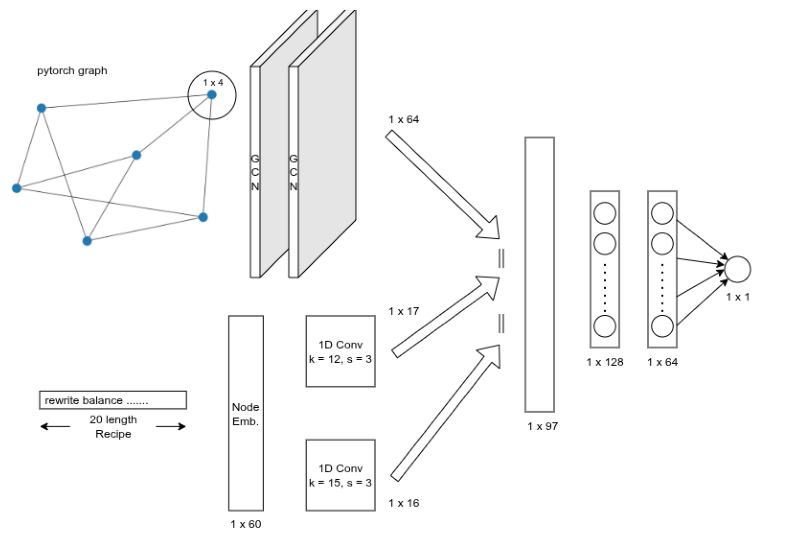

In [25]:
import matplotlib.image as mpimg

img = mpimg.imread("predictor.png") 
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")                   # hide axis
plt.show()

In [26]:
class Predictor(nn.Module):
    def __init__(self, hidden_dim=64, synvec_len=20):
        super().__init__()

        # =========================
        # GCN Layer Declaration
        # =========================
        self.gcn1 = GCNConv(4, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)

        # =========================
        # Node Embedding & Conv Layer Declaration
        # =========================
        self.synth_emb = nn.Embedding(7, 3)  # 7 synth types, embed to dim 3
        self.conv_k12 = nn.Conv1d(1, 1, kernel_size=12, stride=3)  # (60-12)//3+1 = 17 (F = inputshape - kernelsize / stride) + 1
        self.conv_k15 = nn.Conv1d(1, 1, kernel_size=15, stride=3)  # (60-15)//3+1 = 16

        # =========================
        # Final MLP
        # =========================
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim + 17 + 16, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        """
        data.batch must exist if using DataLoader
        """

        # =========================
        # Build Node Features
        # =========================

        # node_type → one-hot
        node_type = F.one_hot(
            data.node_type.long(),
            num_classes=3
        ).float()

        # num_inverted_predecessors
        inv_pred = data.num_inverted_predecessors.view(-1, 1).float() # since node_type → shape (num_nodes, 3) but inv_pred is (num_nodes,) → reshape to (num_nodes, 1) for concatenation

        # concatenate → (num_nodes, 4)
        x = torch.cat([node_type, inv_pred], dim=1)

        # =========================
        # GCN Forward
        # =========================

        x = F.relu(self.gcn1(x, data.edge_index))
        x = F.relu(self.gcn2(x, data.edge_index))

        # graph-level embedding
        x = global_mean_pool(x, data.batch) #shape after: [batch_size, hidden_dim]

        # =========================
        # synVec Branch
        # =========================

        batch_size = data.num_graphs
        synVec = data.synVec.view(batch_size, 20) # reshape to [batch, 20]

        h_syn = torch.cat([self.synth_emb(synVec[:, i]) for i in range(20)], dim=1)  # [batch, 60] self.synth_emb → maps integer → 3D vector
        
        # Apply convolutions
        h_syn_reshaped = h_syn.unsqueeze(1)  # [batch, 1, 60] for conv1d
        conv12_out = self.conv_k12(h_syn_reshaped).squeeze(1)  # [batch, 17]
        conv15_out = self.conv_k15(h_syn_reshaped).squeeze(1)  # [batch, 16]
        
        syn = torch.cat([conv12_out, conv15_out], dim=1)  # [batch, 33]

        # =========================
        # Concat
        # =========================

        fused = torch.cat([x, syn], dim=1) # [batch, 97]

        out = self.mlp(fused) # [batch, 1]

        return out.squeeze(1) # [batch]

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print()
model = Predictor(hidden_dim=64, synvec_len=20).to(device)
print(model)


cuda

Predictor(
  (gcn1): GCNConv(4, 64)
  (gcn2): GCNConv(64, 64)
  (synth_emb): Embedding(7, 3)
  (conv_k12): Conv1d(1, 1, kernel_size=(12,), stride=(3,))
  (conv_k15): Conv1d(1, 1, kernel_size=(15,), stride=(3,))
  (mlp): Sequential(
    (0): Linear(in_features=97, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [28]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [29]:
# compute mean/std from training targets
targets = torch.cat([g.target for g in train_graphs])
mean = targets.mean()
std = targets.std()

for g in train_graphs:
    g.target = (g.target - mean) / std

for g in val_graphs:
    g.target = (g.target - mean) / std

for g in test_graphs:
    g.target = (g.target - mean) / std


In [30]:
def train():
    model.train()
    total_loss = 0

    for data in tqdm(train_loader, desc="Training", leave=False):
        data = data.to(device)

        optimizer.zero_grad() # Reset gradients to zero

        output = model(data)           # forward pass
        loss = criterion(output, data.target.view(-1)) # compute loss

        loss.backward() # compute gradients
        optimizer.step() # update parameters

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)


In [31]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        output = model(data)
        loss = criterion(output, data.target.view(-1))

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)

### TRAIN

In [32]:
train_losses = []
val_losses = []

epochs = 10

for epoch in range(1, epochs + 1):
    train_loss = train()
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 001 | Train: 1.0047 | Val: 1.0565


Epoch 002 | Train: 0.7938 | Val: 0.3375


Epoch 003 | Train: 0.0852 | Val: 0.0192


Epoch 004 | Train: 0.0091 | Val: 0.0057


Epoch 005 | Train: 0.0045 | Val: 0.0046


Epoch 006 | Train: 0.0039 | Val: 0.0042


Epoch 007 | Train: 0.0045 | Val: 0.0072


Epoch 008 | Train: 0.0041 | Val: 0.0041


Epoch 009 | Train: 0.0034 | Val: 0.0038


Epoch 010 | Train: 0.0041 | Val: 0.0049


## Evaluation

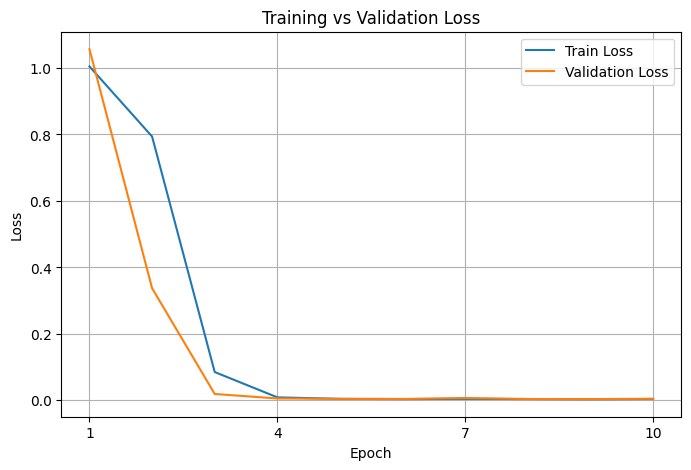

In [33]:
import numpy as np

epochs = len(train_losses)
x = range(1, epochs + 1)

plt.figure(figsize=(8,5))

plt.plot(x, train_losses, label="Train Loss")
plt.plot(x, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Show tick every 3 epochs
plt.xticks(np.arange(1, epochs+1, step=3))

plt.show()



In [35]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data in val_loader:
        data = data.to(device)

        output = model(data)

        all_preds.append(output.cpu())
        all_targets.append(data.target.view(-1).cpu())

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

In [36]:
all_preds = all_preds * std + mean
all_targets = all_targets * std + mean

In [37]:
y_true = all_targets.numpy()
y_pred = all_preds.numpy()

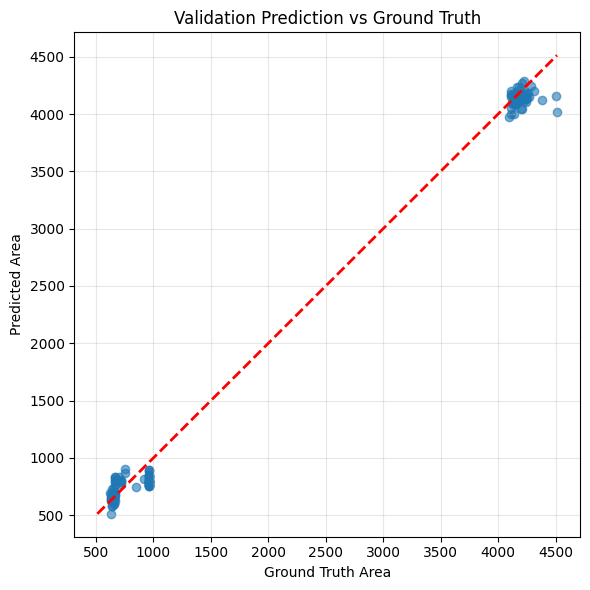

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ground Truth Area")
plt.ylabel("Predicted Area")
plt.title("Validation Prediction vs Ground Truth")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


In [39]:
model.eval()

all_preds = []
all_targets = []

test_loader   = DataLoader(test_graphs, batch_size=16, shuffle=False)

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        output = model(data)

        all_preds.append(output.cpu())
        all_targets.append(data.target.view(-1).cpu())

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

In [40]:
all_preds = all_preds * std + mean
all_targets = all_targets * std + mean

In [41]:
y_true = all_targets.numpy()
y_pred = all_preds.numpy()

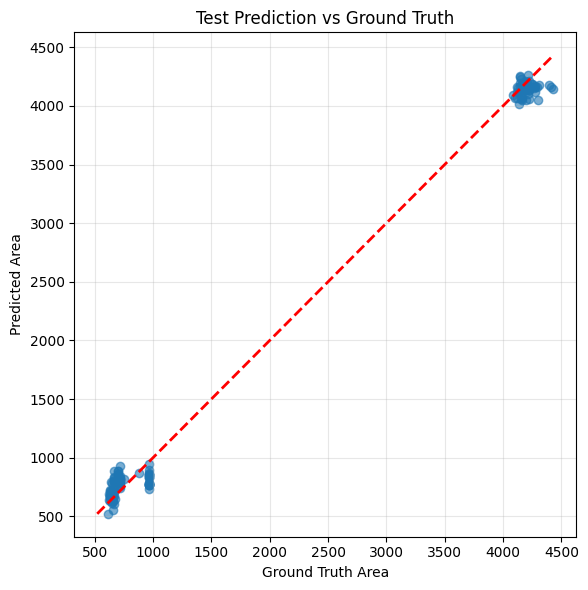

In [42]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ground Truth Area")
plt.ylabel("Predicted Area")
plt.title("Test Prediction vs Ground Truth")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
